MCMC, autocorrelation lenght, 

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [118]:
import corner

In [119]:
data = np.load("transient.npy")

<ErrorbarContainer object of 3 artists>

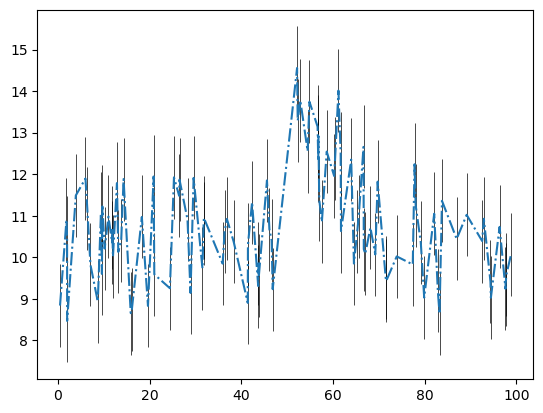

In [120]:
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)

In [121]:
def model(params, t):
    A, b, t0, alpha = params
    arr = []
    for i in t:
        if i<t0:    arr.append(b)
        else:       arr.append(b + A*np.exp(-alpha*(i-t0)))
    arr = np.array(arr)

    return arr

<ErrorbarContainer object of 3 artists>

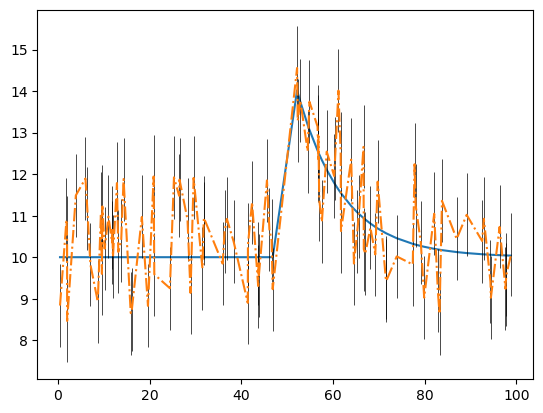

In [122]:
par = 5, 10, 50, 0.1            #from solution
plt.plot(data[:,0], model(par, data[:,0]))
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)

In [123]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

In [124]:
# def Likelihood(params, data, mod=model):
#     sigma = data[:, 2]                  #could use a, b, c = np.transpose(data)
#     y = data[:, 1]
#     t = data[:, 0]
#     y_model = mod(params, t)

#     return np.prod(np.exp(-(y-y_model)**2 /2 /sigma**2))

# def Prior():
#     return 1.0/10

# def myPosterior(params, data, mod=model):
#     return Likelihood(params, data, mod) * Prior()

# # emcee wants ln of posterior pdf
# def myLogPosterior(params, data, mod=model):
#     return np.log(myPosterior(params, data, mod))

incorrectly made a flat prior

In [125]:
def LogLikelihood(theta, data, model=model):
    x, y, sigma_y = data.T
    y_fit = model(theta, x)
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 

## prior is proportional to 1/alpha
def Logprior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 + 0.0 + 0.0 - np.log(alpha)
    return -np.inf
                   
def LogPosterior(theta,data, model=model):
    return LogLikelihood(theta,data, model) + Logprior(theta)

In [126]:
ndim = 4
nwalkers = 20
nsteps = int(1e4)

t0_quick=50
A_quick=5
b_quick=10
alpha_quick=0.1

theta_quick= np.array([A_quick,b_quick,t0_quick,alpha_quick])

#starting_guesses = np.random.randn(nwalkers, ndim)                 #this isn't working
starting_guesses = theta_quick + 1e-1* np.random.randn(nwalkers, ndim)


In [127]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, args=[data, model])
sampler.run_mcmc(starting_guesses, nsteps);

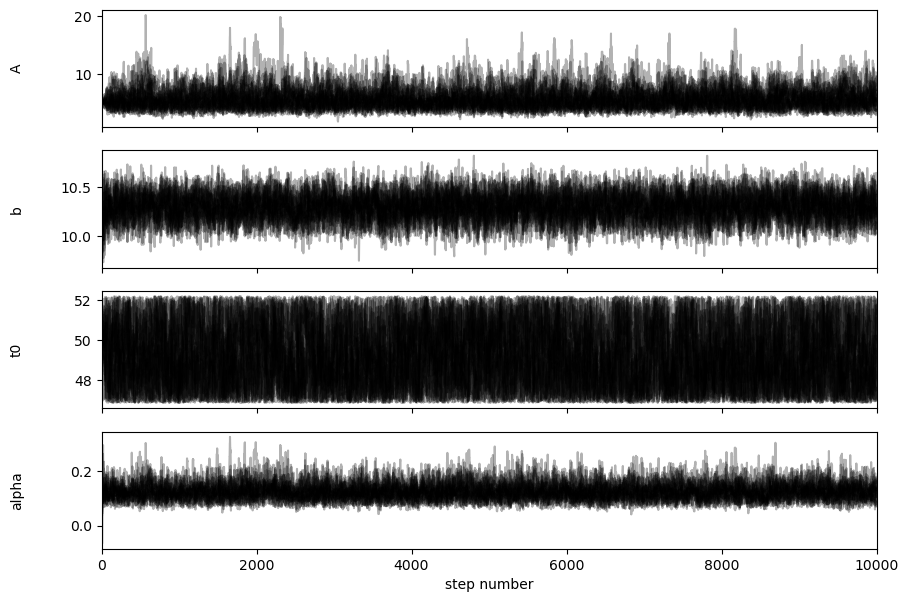

In [128]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A", "b", "t0", "alpha"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [129]:
tau = sampler.get_autocorr_time()
print(tau)

[78.29377296 57.45691603 77.62041986 65.60656418]


In [130]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(2500, 4)


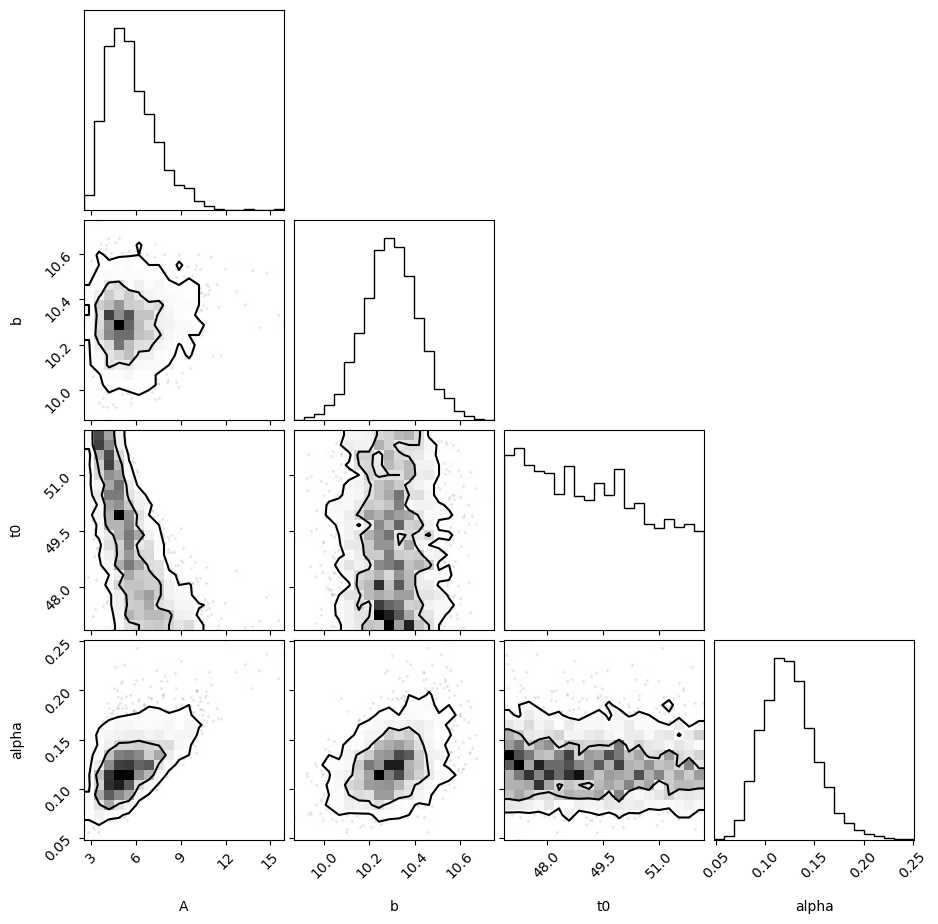

In [131]:
fig = corner.corner(
    flat_samples, labels=labels, levels=[0.68,0.95]
);

In [132]:
chosen_samples= flat_samples[np.random.choice(len(flat_samples), size=100)]

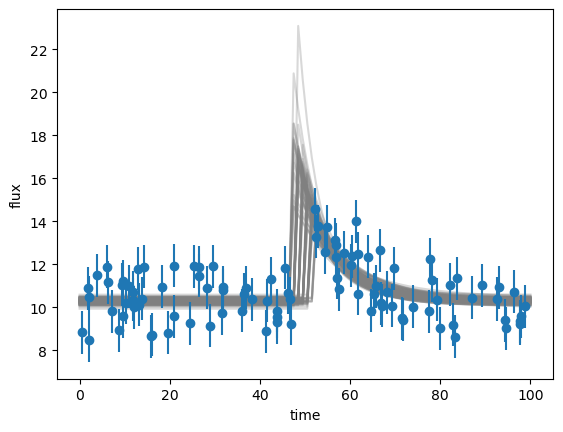

In [133]:
tgrid=np.linspace(0,100,100)

for chosen_theta in chosen_samples:

    ygrid =  model(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o')
plt.xlabel("time")
plt.ylabel("flux");

In [134]:
for i,l in enumerate(labels):
    low,med, up = np.percentile(flat_samples[:,i],[5,50,95]) 
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.398906766788307 +3.4319549312200364 -1.8753256622112149
b   10.295730887549276 +0.1969816074205486 -0.19718308163690956
t0   49.168967155935846 +2.6542370276062144 -2.0991056093223293
alpha   0.1225765812428167 +0.05089545225731065 -0.03772539575776815
